# 01 · Trayectorias — Pruebas APRENDER y Estadística Educativa

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)]
(https://colab.research.google.com/github/santiagoriverti/analisis_pruebas_aprender/blob/main/01_analisis.ipynb)

Visualización **descriptiva** de la evolución en el tiempo de las variables más relevantes.
Consume el dataset de [`00_consolidacion.ipynb`](00_consolidacion.ipynb): en **Colab** lee desde
*Mi unidad/`pruebas_aprender/parquet`*; en **local**, desde `datos_consolidados/`.

## Regla de comparabilidad (define qué se puede graficar como serie)

- **RA — Relevamiento Anual (2011–2025):** mismo diseño todos los años → **series de tiempo válidas**
  (matrícula, trayectoria escolar, cargos docentes, población, infraestructura).
- **APRENDER (2016–2025):** el operativo **cambia de grado/nivel/cobertura** cada año → **no** hay
  serie continua; solo se compara dentro de la misma `(nivel, grado, cobertura)`:
  - **Primaria 6° grado – Censal:** 2016 → 2018 → 2021 → 2023 → 2025.
  - **Secundaria 5-6° año – Censal:** 2016 → 2017 → 2019 → 2022 → 2024.
  - En 2016–2018 el nombre de varios archivos no trae nivel/grado: el notebook 00 los completa y lo verifica con la
    edad más frecuente declarada por los estudiantes (11 años → 6° grado; 17 años → 5-6° año).
  - Escala de desempeño homogénea (4 niveles) salvo Primaria 3° 2024.

## Advertencias de lectura (verificadas contra los datos)

- **Base *Trayectoria* (RA):** el relevamiento del año *t* informa el **ciclo lectivo *t−1*** (matrícula inicial,
  promovidos, no promovidos, salidos sin pase). Los gráficos A.1 y A.2 se rotulan por **ciclo lectivo**.
- **Base *Cargos Bis* (RA):** la columna `total` **mezcla unidades** según `tipo` (cargos, horas cátedra, módulos,
  suplentes, no docentes). Nunca sumar `total` sin filtrar por `tipo`.
- **APRENDER Secundaria Matemática 2022:** la fuente no publica el nivel *Avanzado* (columna vacía).

Al final (sección **D**) se imprime el **listado completo de variables disponibles y su significado**.

---
## 0 · Setup y carga

In [1]:
import os, re, unicodedata
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

def in_colab():
    try:
        import google.colab  # noqa
        return True
    except ImportError:
        return False

if in_colab():
    from google.colab import drive
    drive.mount('/content/drive')
    OUT = '/content/drive/MyDrive/pruebas_aprender/parquet'
else:
    OUT = os.path.join(os.getcwd(), 'datos_consolidados')
assert os.path.isdir(os.path.join(OUT, 'aprender_long')), (
    f'No encuentro el dataset en {OUT}. Corré primero 00_consolidacion.ipynb.')
plt.rcParams['figure.dpi'] = 110

# Carpeta donde se guardan los gráficos en alta resolución (300 dpi) para descargar al final
GRAF = os.path.abspath('graficos_trayectorias'); os.makedirs(GRAF, exist_ok=True)
_figs = []  # registro de gráficos generados
def guardar(fig, nombre):
    ruta = os.path.join(GRAF, nombre + '.png')
    fig.savefig(ruta, dpi=300, bbox_inches='tight')
    _figs.append(nombre); return fig
print('Datos consolidados en:', OUT)
print('Los gráficos (300 dpi) se guardarán en:', GRAF)

Datos consolidados en: C:\Users\sriverti\Desktop\INECO\Repositorios\analisis_pruebas_aprender\datos_consolidados
Los gráficos (300 dpi) se guardarán en: C:\Users\sriverti\Desktop\INECO\Repositorios\analisis_pruebas_aprender\graficos_trayectorias


---
## 1 · Funciones

In [2]:
def cargar_ra(base):
    return pd.read_parquet(os.path.join(OUT, 'ra', f'ra_{base}.parquet'))
def cargar_aprender(anio, cols=None):
    return pd.read_parquet(os.path.join(OUT, 'aprender_long', f'anio={anio}'), columns=cols)

# --- RA: sumar columnas por año de estudio (rangos: primaria 1-6, secundaria 7-12, total 1-12) ---
PRIM, SEC, TOTAL = range(1, 7), range(7, 13), range(1, 13)
def suma_anios(df, prefijo, anios_estudio):
    cols = [f'{prefijo}_{i}' for i in anios_estudio if f'{prefijo}_{i}' in df.columns]
    return df.groupby('anio')[cols].sum().sum(axis=1)
def tasa(df, numerador, anios_estudio):
    return (suma_anios(df, numerador, anios_estudio) / suma_anios(df, 'inicial', anios_estudio) * 100)

# --- RA Trayectoria: el relevamiento del año t informa el ciclo lectivo t-1 ---
NOTA_CICLO = ('Base Trayectoria (RA): el relevamiento del año t informa el ciclo lectivo t−1; '
              'el eje muestra el ciclo lectivo.')
def a_ciclo_lectivo(tabla):
    out = tabla.copy(); out.index = out.index - 1; out.index.name = 'ciclo_lectivo'
    return out

# --- Estilo de líneas: la serie 'Total' en negro punteado, el resto línea con marcador ---
def estilo_total(columnas):
    return {col: ('k--o' if str(col).startswith('Total') else '-o') for col in columnas}
def nota(fig, texto):
    fig.text(0.01, -0.03, texto, fontsize=8, color='gray', ha='left', va='top')

# --- APRENDER: años de cada cohorte comparable (misma nivel/grado/cobertura) ---
ANIOS_PRIM6 = [2016, 2018, 2021, 2023, 2025]   # Primaria 6° grado, Censal
ANIOS_SEC56 = [2016, 2017, 2019, 2022, 2024]   # Secundaria 5-6° año, Censal

# --- APRENDER: armonización de niveles de desempeño (escala de 4) ---
ORDEN4 = ['Por debajo del básico', 'Básico', 'Satisfactorio', 'Avanzado']
def _n(s):
    s = unicodedata.normalize('NFKD', str(s)).encode('ascii','ignore').decode().lower()
    return re.sub(r'[^a-z0-9]+', ' ', s).strip()
def harmonizar_nivel(op):
    t = _n(op)
    if 'por debajo' in t: return 'Por debajo del básico'
    if t == 'basico': return 'Básico'
    if 'satisfactorio' in t: return 'Satisfactorio'
    if 'avanzado' in t: return 'Avanzado'
    return None
def cargar_desempeno(anio):
    d = cargar_aprender(anio)
    d = d[d.tipo_variable == 'desempeño'].copy()
    d['nivel_desemp'] = d['variable'].str.split('_', n=1).str[1].map(harmonizar_nivel)
    d['anio'] = anio
    return d
def desempeno_pct(df, group_cols):
    d = df.dropna(subset=['nivel_desemp'])
    t = (d.groupby(list(group_cols) + ['nivel_desemp'], observed=True)['valor'].sum()
           .unstack('nivel_desemp').reindex(columns=ORDEN4))
    return t.div(t.sum(axis=1), axis=0) * 100
def serie_cohorte(nivel, grado, cobertura, area, anios):
    df = pd.concat([cargar_desempeno(a) for a in anios], ignore_index=True)
    coh = df[(df.nivel==nivel)&(df.grado==grado)&(df.cobertura==cobertura)&(df.area==area)]
    return desempeno_pct(coh, ['anio'])
print('Funciones listas.')

Funciones listas.


---
## 2 · Mapa de comparabilidad (cohortes APRENDER)
Matriz `(nivel, grado, cobertura, área) × año`. Las filas con varias `X` en la misma cobertura son
las series comparables.

In [3]:
filas = []
for a in sorted(os.listdir(os.path.join(OUT, 'aprender_long'))):
    anio = int(a.split('=')[1])
    d = cargar_aprender(anio, cols=['cobertura','nivel','grado','area','tipo_variable'])
    for k, _ in d[d.tipo_variable=='desempeño'].groupby(['nivel','grado','cobertura','area'], observed=True):
        filas.append((*k, anio))
mapa = pd.DataFrame(filas, columns=['nivel','grado','cobertura','area','anio'])
mapa.assign(x='X').pivot_table(index=['nivel','grado','cobertura','area'], columns='anio',
        values='x', aggfunc='first', observed=True).fillna('')

anio                                            2016 2017 2018 2019 2021 2022  \
nivel      grado   cobertura area                                               
Primaria   3 grado Muestral  Lengua                X                            
                             Matematica            X                            
           6 grado Censal    Ciencias Naturales         X                       
                             Ciencias Sociales          X                       
                             Lengua                X         X         X        
                             Matematica            X         X         X        
                   Muestral  Lengua                                         X   
                             Matematica                                     X   
Secundaria 2-3 año Muestral  Lengua                X                            
                             Matematica            X                            
           5-6 año Censal    Ciencias Naturales    X                            
                             Ciencias Sociales     X                            
                             Lengua                X    X         X         X   
                             Matematica            X    X         X         X   
                   Muestral  Ciencias Naturales                   X             
                             Ciudadania                           X             

anio                                            2023 2024 2025  
nivel      grado   cobertura area                               
Primaria   3 grado Muestral  Lengua                     X       
                             Matematica                         
           6 grado Censal    Ciencias Naturales                 
                             Ciencias Sociales                  
                             Lengua                X         X  
                             Matematica            X         X  
                   Muestral  Lengua                             
                             Matematica                         
Secundaria 2-3 año Muestral  Lengua                             
                             Matematica                         
           5-6 año Censal    Ciencias Naturales                 
                             Ciencias Sociales                  
                             Lengua                     X       
                             Matematica                 X       
                   Muestral  Ciencias Naturales                 
                             Ciudadania

---
# A · Trayectorias de estadística educativa (RA, 2011–2025)

### A.1 · Matrícula inicial por nivel
Matrícula inicial (base *Trayectoria*) por **ciclo lectivo**. La matrícula **secundaria crece** (expansión de
cobertura) mientras la primaria se mantiene.

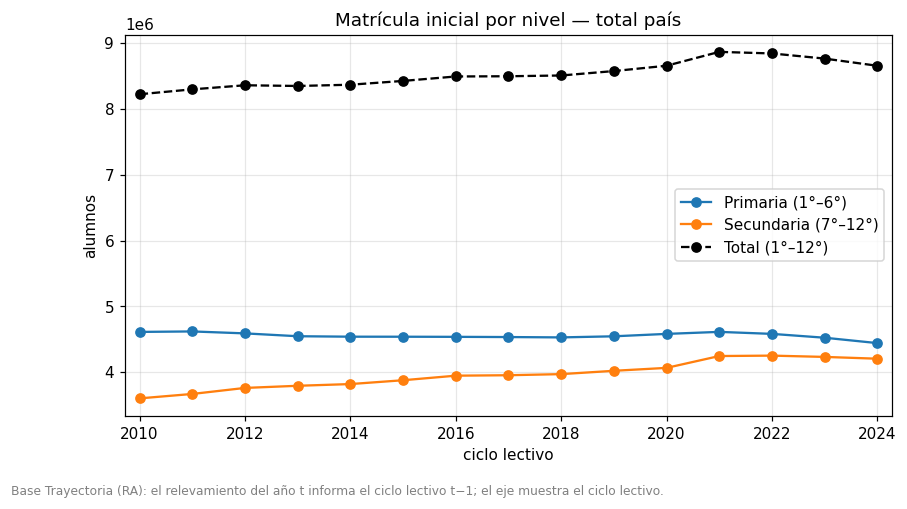

,Primaria (1°–6°),Secundaria (7°–12°),Total (1°–12°)
ciclo_lectivo,,,
2010,4.61,3.61,8.22
2011,4.62,3.67,8.29
2012,4.59,3.76,8.36
2013,4.55,3.80,8.34
2014,4.54,3.82,8.36
2015,4.54,3.88,8.42
2016,4.54,3.95,8.49
2017,4.54,3.96,8.49
2018,4.53,3.97,8.50


In [4]:
tr = cargar_ra('trayectoria')
mat = a_ciclo_lectivo(pd.DataFrame({'Primaria (1°–6°)': suma_anios(tr, 'inicial', PRIM),
                                    'Secundaria (7°–12°)': suma_anios(tr, 'inicial', SEC),
                                    'Total (1°–12°)': suma_anios(tr, 'inicial', TOTAL)}))
fig, ax = plt.subplots(figsize=(9,4.5))
mat.plot(ax=ax, title='Matrícula inicial por nivel — total país', style=estilo_total(mat.columns))
ax.set_xlabel('ciclo lectivo'); ax.set_ylabel('alumnos'); ax.grid(alpha=.3); ax.margins(x=.02)
nota(fig, NOTA_CICLO)
guardar(fig, 'A1_matricula_por_nivel'); plt.show()
(mat/1e6).round(2)

### A.2 · Tasa de repitencia y de abandono
Repitencia = `no promovidos / matrícula inicial`; abandono = `salidos sin pase / matrícula inicial`, por **ciclo lectivo**.
Ambas **bajan** en el período, sobre todo en secundaria. La caída abrupta del **ciclo 2020** coincide con la
pandemia (unidad pedagógica 2020-2021, sin repitencia); la repitencia se recupera parcialmente desde 2021.

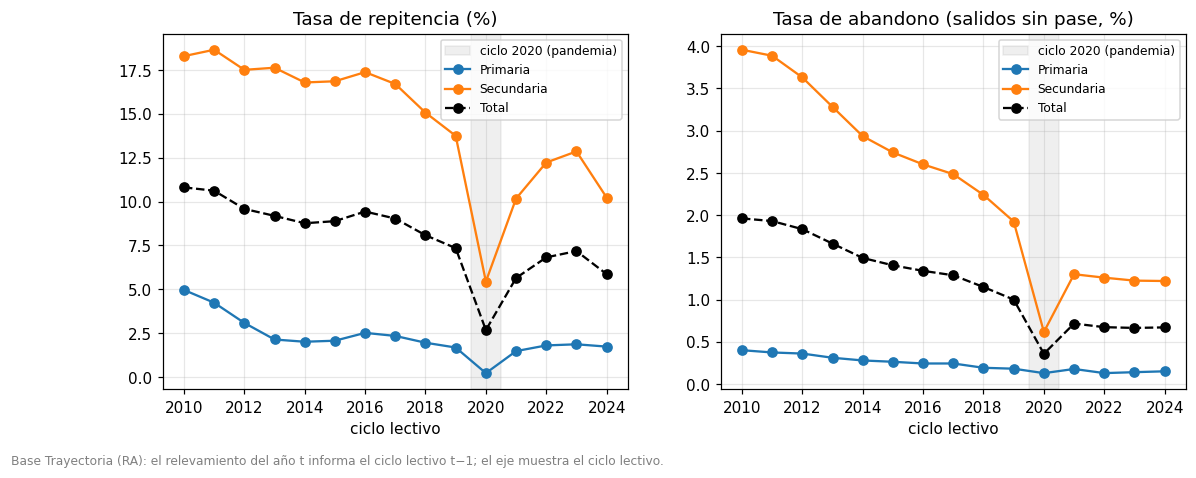

repitencia                  abandono                 
                Primaria Secundaria Total Primaria Secundaria Total
ciclo_lectivo                                                      
2010                 5.0       18.3  10.8      0.4        4.0   2.0
2011                 4.2       18.7  10.6      0.4        3.9   1.9
2012                 3.1       17.5   9.6      0.4        3.6   1.8
2013                 2.1       17.6   9.2      0.3        3.3   1.7
2014                 2.0       16.8   8.8      0.3        2.9   1.5
2015                 2.1       16.9   8.9      0.3        2.7   1.4
2016                 2.5       17.4   9.4      0.2        2.6   1.3
2017                 2.3       16.7   9.0      0.2        2.5   1.3
2018                 2.0       15.1   8.1      0.2        2.2   1.1
2019                 1.7       13.7   7.3      0.2        1.9   1.0
2020                 0.2        5.4   2.7      0.1        0.6   0.4
2021                 1.5       10.2   5.6      0.2        1.3   0.7
2022                 1.8       12.2   6.8      0.1        1.3   0.7
2023                 1.9       12.9   7.2      0.1        1.2   0.7
2024                 1.7       10.2   5.9      0.2        1.2   0.7

In [5]:
rep = a_ciclo_lectivo(pd.DataFrame({'Primaria': tasa(tr,'nopromo',PRIM), 'Secundaria': tasa(tr,'nopromo',SEC), 'Total': tasa(tr,'nopromo',TOTAL)}))
aba = a_ciclo_lectivo(pd.DataFrame({'Primaria': tasa(tr,'ssp',PRIM), 'Secundaria': tasa(tr,'ssp',SEC), 'Total': tasa(tr,'ssp',TOTAL)}))
fig, ax = plt.subplots(1, 2, figsize=(12,4.2), sharex=True)
for a, tabla, titulo in [(ax[0], rep, 'Tasa de repitencia (%)'), (ax[1], aba, 'Tasa de abandono (salidos sin pase, %)')]:
    a.axvspan(2019.5, 2020.5, color='gray', alpha=.12, label='ciclo 2020 (pandemia)')
    tabla.plot(ax=a, style=estilo_total(tabla.columns), title=titulo)
    a.grid(alpha=.3); a.set_xlabel('ciclo lectivo'); a.legend(fontsize=8)
nota(fig, NOTA_CICLO)
guardar(fig, 'A2_repitencia_abandono'); plt.show()
pd.concat({'repitencia': rep.round(1), 'abandono': aba.round(1)}, axis=1)

### A.3 · Cargos docentes
Base *Cargos Bis*. **Ojo:** la columna `total` mezcla unidades según `tipo` (cargos, horas cátedra, módulos,
suplentes y no docentes), así que se separa por `tipo`. Acá se grafican solo los **cargos docentes**
(`tipo == 'Cargos'`: titulares, interinos, fuera de planta y sin cubrir), por nivel. La tabla muestra todos los tipos.

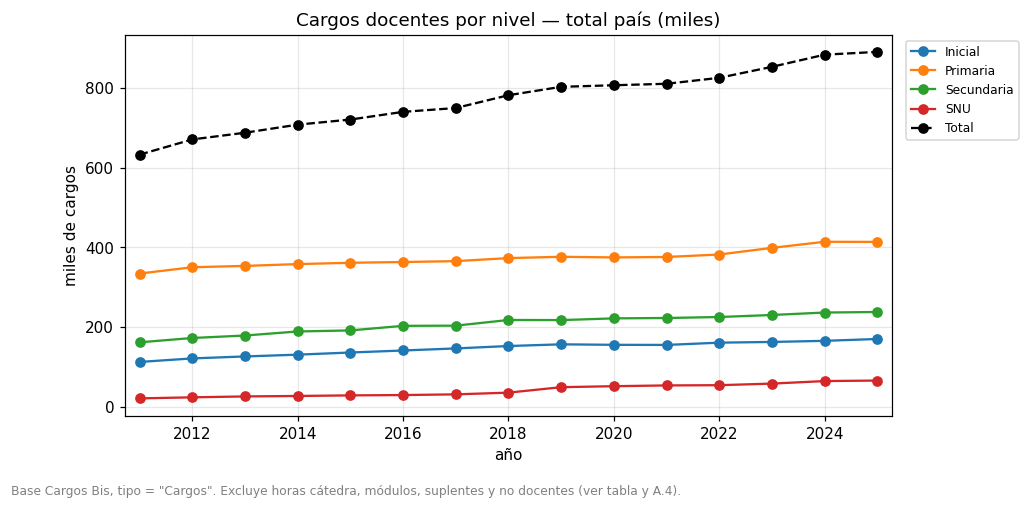

Total de la columna `total` por tipo (cada tipo en su propia unidad):


tipo,Cargos,Cargos Suplentes,Cargos No Docentes,Horas,Horas Suplentes,Módulos,Módulos Suplentes
anio,,,,,,,
2011,632494,108931,156954,4630234,583770,1856358,236598
2012,670579,117892,170958,4750850,613358,1900818,272158
2013,687348,127171,171394,5053629,697861,1987659,277711
2014,707580,128748,179613,5298323,723685,1981408,282205
2015,720362,139554,178417,5571266,790135,2028874,271831
2016,739636,140518,182973,5659676,841806,2168699,277987
2017,749222,139884,247305,5968367,838103,2182261,270902
2018,781327,140060,209128,6034306,846376,2145346,249206
2019,802301,140755,211378,6100276,908059,2163639,235013


In [6]:
cb = cargar_ra('cargos_bis')
for col in ['nivel', 'tipo']:
    cb[col] = cb[col].astype(str).str.strip()
TIPOS_CB = ['Cargos', 'Cargos Suplentes', 'Cargos No Docentes', 'Horas', 'Horas Suplentes', 'Módulos', 'Módulos Suplentes']
# `total` mide cosas distintas según `tipo` → se agrega siempre por tipo, nunca todo junto
por_tipo = cb.groupby(['anio', 'tipo'])['total'].sum().unstack('tipo').reindex(columns=TIPOS_CB)
cargos = (cb[cb.tipo == 'Cargos'].groupby(['anio', 'nivel'])['total'].sum().unstack('nivel')
            .reindex(columns=['Inicial', 'Primaria', 'Secundaria', 'SNU']))
cargos['Total'] = por_tipo['Cargos']
fig, ax = plt.subplots(figsize=(9,4.5))
(cargos/1e3).plot(ax=ax, style=estilo_total(cargos.columns), title='Cargos docentes por nivel — total país (miles)')
ax.set_xlabel('año'); ax.set_ylabel('miles de cargos'); ax.grid(alpha=.3); ax.margins(x=.02)
ax.legend(bbox_to_anchor=(1.01, 1), fontsize=8)
nota(fig, 'Base Cargos Bis, tipo = "Cargos". Excluye horas cátedra, módulos, suplentes y no docentes (ver tabla y A.4).')
guardar(fig, 'A3_cargos_docentes'); plt.show()
print('Total de la columna `total` por tipo (cada tipo en su propia unidad):')
por_tipo.round(0).astype('Int64')

### A.4 · Horas cátedra y módulos
Mismas fuente y advertencia que A.3: las **horas cátedra** y los **módulos** son unidades de dedicación (no
personas ni cargos). Se muestran titulares/interinos y suplentes por separado.

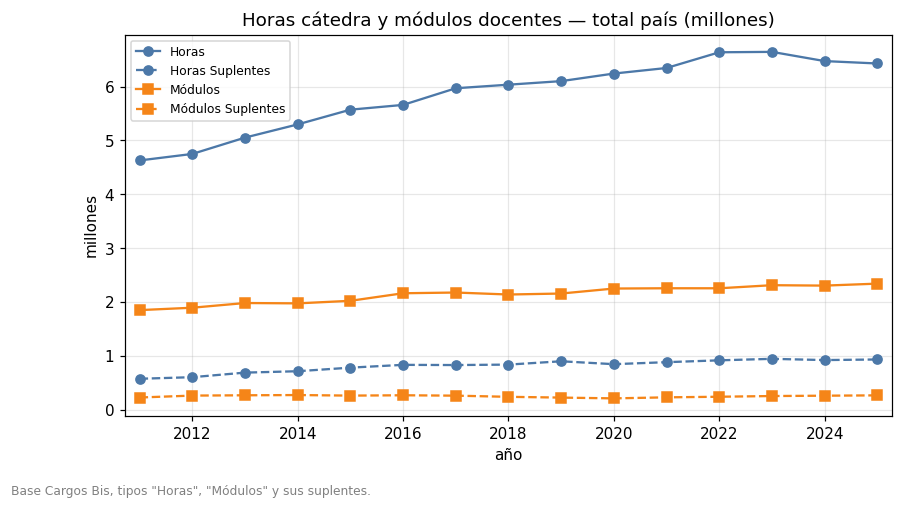

tipo,Horas,Horas Suplentes,Módulos,Módulos Suplentes
anio,,,,
2011,4.63,0.58,1.86,0.24
2012,4.75,0.61,1.90,0.27
2013,5.05,0.70,1.99,0.28
2014,5.30,0.72,1.98,0.28
2015,5.57,0.79,2.03,0.27
2016,5.66,0.84,2.17,0.28
2017,5.97,0.84,2.18,0.27
2018,6.03,0.85,2.15,0.25
2019,6.10,0.91,2.16,0.24


In [7]:
hm = por_tipo[['Horas', 'Horas Suplentes', 'Módulos', 'Módulos Suplentes']] / 1e6
fig, ax = plt.subplots(figsize=(9,4.5))
for col, fmt, color in [('Horas', '-o', '#4C78A8'), ('Horas Suplentes', '--o', '#4C78A8'),
                        ('Módulos', '-s', '#F58518'), ('Módulos Suplentes', '--s', '#F58518')]:
    ax.plot(hm.index, hm[col], fmt, color=color, label=col)
ax.set_title('Horas cátedra y módulos docentes — total país (millones)')
ax.set_xlabel('año'); ax.set_ylabel('millones'); ax.grid(alpha=.3); ax.margins(x=.02); ax.legend(fontsize=8)
nota(fig, 'Base Cargos Bis, tipos "Horas", "Módulos" y sus suplentes.')
guardar(fig, 'A4_horas_modulos'); plt.show()
hm.round(2)

---
# B · Trayectorias de desempeño (APRENDER, cohortes comparables)
Solo dentro de la misma `(nivel, grado, cobertura)`. `valor` = conteo ponderado → se convierte a %.

### B.1 · Primaria 6° grado (Censal): 2016 · 2018 · 2021 · 2023 · 2025

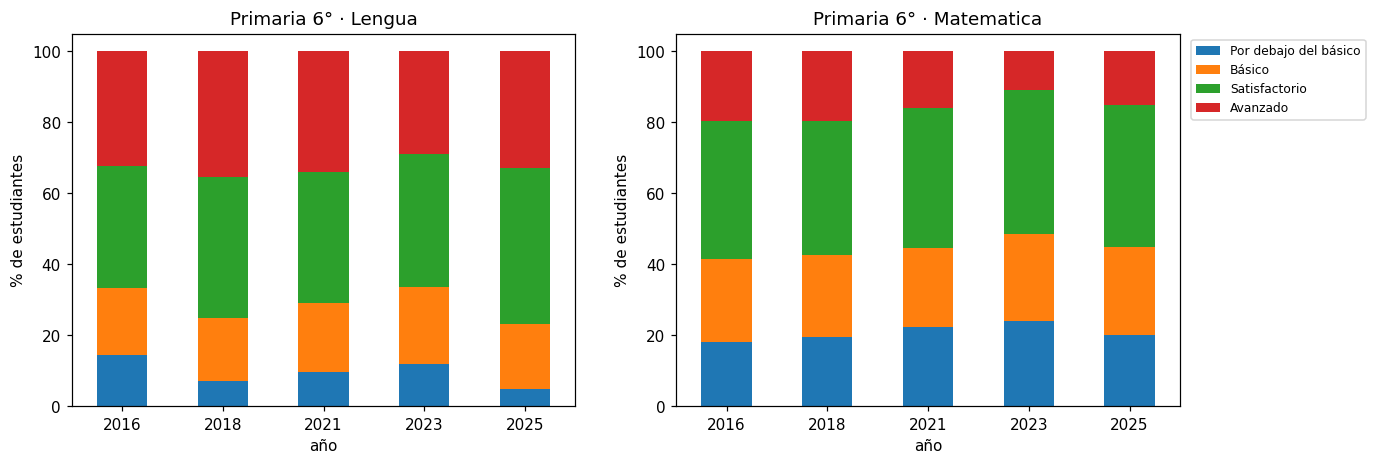

% Satisfactorio+Avanzado — Primaria 6°:


,Lengua,Matematica
anio,,
2016,66.8,58.5
2018,75.3,57.4
2021,70.9,55.5
2023,66.4,51.4
2025,76.9,55.0


In [8]:
anios_p = ANIOS_PRIM6
fig, ax = plt.subplots(1, 2, figsize=(13,4.4))
for i, area in enumerate(['Lengua', 'Matematica']):
    s = serie_cohorte('Primaria', '6 grado', 'Censal', area, anios_p)
    s.plot(kind='bar', stacked=True, ax=ax[i], title=f'Primaria 6° · {area}')
    ax[i].set_xlabel('año'); ax[i].set_ylabel('% de estudiantes'); ax[i].tick_params(axis='x', rotation=0)
    ax[i].legend().set_visible(i==1)
if ax[1].get_legend(): ax[1].legend(bbox_to_anchor=(1.01,1), fontsize=8)
guardar(fig, 'B1_desempeno_primaria6'); plt.show()
# Resumen: % Satisfactorio+Avanzado por año y área
resumen_p = pd.DataFrame({area: serie_cohorte('Primaria','6 grado','Censal',area,anios_p)[['Satisfactorio','Avanzado']].sum(axis=1)
                          for area in ['Lengua','Matematica']})
print('% Satisfactorio+Avanzado — Primaria 6°:'); resumen_p.round(1)

### B.2 · Secundaria 5-6° año (Censal): 2016 · 2017 · 2019 · 2022 · 2024
- **Matemática 2022:** la fuente no publica el nivel *Avanzado* (la columna viene vacía), por eso esa barra no lo muestra.
  En 2024 Avanzado es apenas ~0,1%.
- 2022 y 2024 dan valores **casi idénticos** de % Satisfactorio+Avanzado (Lengua 56,94 vs 56,89; Matemática 17,64 vs 17,63).
  No es un error: son datos distintos que coinciden al redondear. El resumen se muestra con 2 decimales.

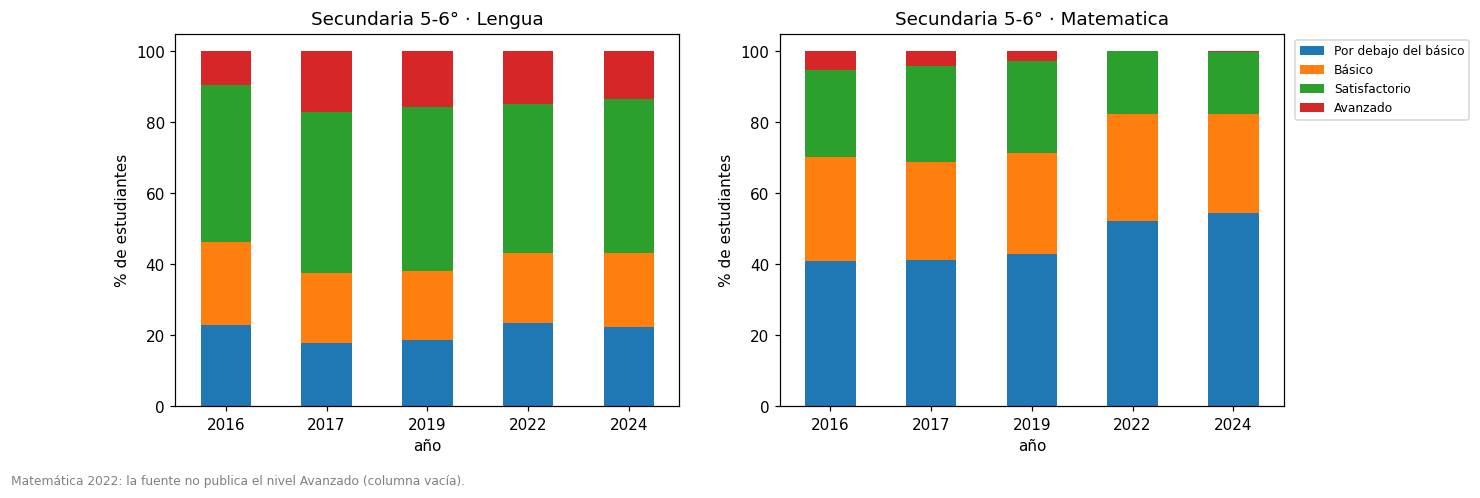

% Satisfactorio+Avanzado — Secundaria 5-6°:


,Lengua,Matematica
anio,,
2016,53.65,29.81
2017,62.53,31.13
2019,61.76,28.66
2022,56.94,17.64
2024,56.89,17.63


In [9]:
anios_s = ANIOS_SEC56
fig, ax = plt.subplots(1, 2, figsize=(13,4.4))
for i, area in enumerate(['Lengua', 'Matematica']):
    s = serie_cohorte('Secundaria', '5-6 año', 'Censal', area, anios_s)
    s.plot(kind='bar', stacked=True, ax=ax[i], title=f'Secundaria 5-6° · {area}')
    ax[i].set_xlabel('año'); ax[i].set_ylabel('% de estudiantes'); ax[i].tick_params(axis='x', rotation=0)
    ax[i].legend().set_visible(i==1)
if ax[1].get_legend(): ax[1].legend(bbox_to_anchor=(1.01,1), fontsize=8)
nota(fig, 'Matemática 2022: la fuente no publica el nivel Avanzado (columna vacía).')
guardar(fig, 'B2_desempeno_secundaria56'); plt.show()
resumen_s = pd.DataFrame({area: serie_cohorte('Secundaria','5-6 año','Censal',area,anios_s)[['Satisfactorio','Avanzado']].sum(axis=1)
                          for area in ['Lengua','Matematica']})
print('% Satisfactorio+Avanzado — Secundaria 5-6°:'); resumen_s.round(2)

### B.3 · La trayectoria por sector (Estatal vs Privado)
Descriptivo: cómo evoluciona el % (Satisfactorio+Avanzado) por sector dentro de una cohorte.

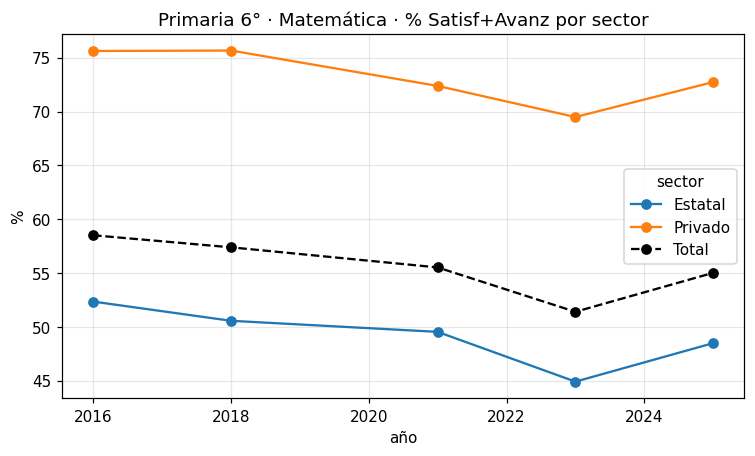

sector,Estatal,Privado,Total
anio,,,
2016,52.4,75.6,58.5
2018,50.6,75.7,57.4
2021,49.5,72.4,55.5
2023,44.9,69.5,51.4
2025,48.5,72.7,55.0


In [10]:
def serie_sector(nivel, grado, cobertura, area, anios):
    df = pd.concat([cargar_desempeno(a) for a in anios], ignore_index=True)
    coh = df[(df.nivel==nivel)&(df.grado==grado)&(df.cobertura==cobertura)&(df.area==area)]
    pct = desempeno_pct(coh, ['anio','sector'])
    return (pct[['Satisfactorio','Avanzado']].sum(axis=1)).unstack('sector')
g = serie_sector('Primaria','6 grado','Censal','Matematica',ANIOS_PRIM6)
g['Total'] = serie_cohorte('Primaria','6 grado','Censal','Matematica',ANIOS_PRIM6)[['Satisfactorio','Avanzado']].sum(axis=1)
fig, ax = plt.subplots(figsize=(8,4.3))
g.plot(ax=ax, style=estilo_total(g.columns), title='Primaria 6° · Matemática · % Satisf+Avanz por sector')
ax.set_xlabel('año'); ax.set_ylabel('%'); ax.grid(alpha=.3); ax.margins(x=.05)
guardar(fig, 'B3_sector_primaria6_matematica'); plt.show()
g.round(1)

---
## Cómo extender

- **Otras cohortes/áreas:** `serie_cohorte('Secundaria','5-6 año','Censal','Lengua',ANIOS_SEC56)`.
- **Más trayectorias RA:** promoción (`tasa(tr,'promovidos',PRIM)`), sobreedad (base *Matrícula por edad*),
  población/infraestructura (base *Características*). Series de la base *Trayectoria* → pasar por `a_ciclo_lectivo()`.
- **Cargos Bis:** filtrar siempre por `tipo` antes de sumar `total` (`cb[cb.tipo == 'Cargos']`).
- **Cortes geográficos:** filtrar por `provincia`/`jurisdiccion` antes de agregar.
- **Qué variables hay y qué significan:** sección **D** (al final). Después de correrla:
  `buscar_variable('repitencia')`, o filtrar las tablas `variables_ra` / `variables_aprender`.

> Unidades: APRENDER = conteos **ponderados** (se pasan a % por celda); RA = conteos **absolutos**.
> No comparar cohortes APRENDER de distinto grado/nivel entre sí.

---
## C · Descargar los gráficos (300 dpi)
Todos los gráficos se guardaron en alta resolución (300 dpi) en `graficos_trayectorias/`.
Al ejecutar en **Colab**, esta celda los comprime en un `.zip` y **lo descarga** a tu computadora.

In [11]:
import shutil
print('Gráficos generados (300 dpi):')
for n in _figs: print('  -', n + '.png')
zip_base = os.path.join(os.path.dirname(GRAF), 'graficos_trayectorias')
zip_path = shutil.make_archive(zip_base, 'zip', GRAF)
print('\nZIP:', zip_path, f'({os.path.getsize(zip_path)/1e6:.1f} MB)')
if in_colab():
    from google.colab import files
    files.download(zip_path)   # descarga el zip a tu máquina
    print('Descargando el zip...')
else:
    print('Entorno local: los PNG quedan en', GRAF)

Gráficos generados (300 dpi):
  - A1_matricula_por_nivel.png
  - A2_repitencia_abandono.png
  - A3_cargos_docentes.png
  - A4_horas_modulos.png
  - B1_desempeno_primaria6.png
  - B2_desempeno_secundaria56.png
  - B3_sector_primaria6_matematica.png

ZIP: C:\Users\sriverti\Desktop\INECO\Repositorios\analisis_pruebas_aprender\graficos_trayectorias.zip (0.9 MB)
Entorno local: los PNG quedan en C:\Users\sriverti\Desktop\INECO\Repositorios\analisis_pruebas_aprender\graficos_trayectorias


---
## D · Variables disponibles y su significado

Listado **completo** armado desde los **datos** (qué columnas/variables existen y en qué años) con el significado
tomado de los **diccionarios oficiales** consolidados por el notebook 00.

- **RA:** una línea por columna, agrupando las series numeradas (p. ej. `inicial_{1–12, 20, 1314}`), con los años con dato.
- **APRENDER:** una entrada por **pregunta**, con los años/niveles en que aparece, sus códigos y sus opciones de respuesta.
  Cada `variable` de la tabla es `código_opción`.

Además deja en memoria `variables_ra`, `variables_aprender` y la función `buscar_variable(texto)`.
Tarda ~30–60 s (recorre todas las variables).

In [12]:
# Catálogo de variables disponibles: se arma desde los DATOS (qué columnas/variables existen y en qué años)
# y se le pega el significado desde los diccionarios oficiales consolidados por el notebook 00.
import textwrap
import pyarrow.dataset as pads
ANCHO = 130

def _clave(s):
    s = unicodedata.normalize('NFKD', str(s)).encode('ascii', 'ignore').decode().lower()
    return re.sub(r'[^a-z0-9]', '', s)

def _anios_txt(anios):
    a = sorted({int(x) for x in anios})
    if not a: return 'sin datos'
    tramos, ini, prev = [], a[0], a[0]
    for x in a[1:] + [None]:
        if x is not None and x == prev + 1:
            prev = x; continue
        tramos.append(str(ini) if ini == prev else (f'{ini}, {prev}' if prev == ini + 1 else f'{ini}–{prev}'))
        if x is not None: ini = prev = x
    return ', '.join(tramos)

def _p(texto, sangria=0):
    pref = ' ' * sangria
    print(textwrap.fill(str(texto), ANCHO, initial_indent=pref, subsequent_indent=pref + '    '))

def _sufijos_txt(sufijos):
    nums = sorted(int(s) for s in sufijos if len(s) <= 2)
    otros = [s for s in sufijos if len(s) > 2]
    return ', '.join(([_anios_txt(nums)] if nums else []) + otros)

# ============================ RA — Relevamiento Anual ============================
BASES_RA = [
    ('trayectoria', 'Trayectoria',
     'Flujo de alumnos del ciclo lectivo ANTERIOR al relevamiento (año t informa el ciclo t−1): matrícula inicial, '
     'entrados, salidos con/sin pase, matrícula al último día, promovidos y no promovidos, por año de estudio.'),
    ('matricula', 'Matricula',
     'Alumnos matriculados en el año del relevamiento por sala/año de estudio; v_ = varones, r_ = repitentes, '
     's_ = alumnos con sobreedad, _sec = secciones.'),
    ('matricula_por_edad', 'Matricula por edad',
     'Alumnos por edad (una columna por edad) para cada grado/sala (columna `grado`: una fila por grado).'),
    ('cargos', 'Cargos',
     'Cargos y horas docentes en formato ancho: nivel (ini/pri/sec/snu) × función (dir = dirección, fte = frente a '
     'alumnos, apo = apoyo, pu = personal único, hs = horas) × situación (cub = cubiertos, ncub = no cubiertos, '
     'nopof/fuera = fuera de planta).'),
    ('cargos_bis', 'Cargos Bis',
     'Mismo universo que Cargos en formato LARGO (una fila por nivel × función × tipo × cargo × planta). '
     'OJO: `total` mezcla unidades según `tipo` (cargos, horas, módulos): nunca sumar sin filtrar por `tipo`.'),
    ('caracteristicas', 'Caracteristicas',
     'Infraestructura y equipamiento de las unidades educativas (electricidad, equipamiento, internet, biblioteca, '
     'cooperadora, gestión). Muchas columnas vienen como texto: convertir con pd.to_numeric(..., errors="coerce").'),
    ('poblacion', 'Poblacion',
     'Características de la población escolar (población indígena, idiomas, alumnos extranjeros por origen, '
     'alimentación, discapacidad), por nivel. Muchas columnas vienen como texto: usar pd.to_numeric(..., errors="coerce").'),
]
CLAVES_RA = {'anio': 'Año del relevamiento', 'provincia': 'Provincia', 'departamento': 'Departamento',
             'sector': 'Estatal / Privado', 'ambito': 'Urbano / Rural'}
CATEGORICAS_RA = {'cargos_bis': ['nivel', 'tipo', 'categoria', 'planta_tipo', 'cargo'], 'matricula_por_edad': ['grado']}

dic_ra = pd.read_parquet(os.path.join(OUT, 'diccionario_ra.parquet'))
filas_ra = []
print('=' * ANCHO)
print('VARIABLES DISPONIBLES — RA (Relevamiento Anual, estadística educativa). Valores = conteos ABSOLUTOS.')
print('=' * ANCHO)
_p('Claves comunes a todas las bases: ' + '; '.join(f'{k} = {v}' for k, v in CLAVES_RA.items()) + '.')
_p('Sufijos de año de estudio: 1–6 ≈ primaria, 7–12 ≈ secundaria (años corridos), 1314 = 13° y 14° año, '
   '20 = organización no graduada, snu = Superior No Universitario; s2–s5 = salas de 2 a 5 años.')
for archivo, nombre_dic, descripcion in BASES_RA:
    df = cargar_ra(archivo)
    dic = dic_ra[dic_ra.base == nombre_dic]
    exacto = dict(zip(dic.campo, dic.contenido))
    normal = {_clave(c): t for c, t in zip(dic.campo, dic.contenido)}
    def _sig(col):  # primero nombre exacto (evita choques como s2 = sala de 2 vs s_2 = sobreedad 2°)
        return exacto.get(col) or normal.get(_clave(col))
    cols = [c for c in df.columns if c not in CLAVES_RA and c != 'Localizacion']
    # año con dato = al menos un valor no nulo y no vacío en esa columna
    presentes = (df[cols].notna() & df[cols].astype(str).apply(lambda s: s.str.strip() != '')).groupby(df['anio']).any()
    print('\n' + '-' * ANCHO)
    print(f'BASE: {nombre_dic}  ·  cargar_ra("{archivo}")  ·  {len(df):,} filas  ·  años {_anios_txt(df.anio.unique())}')
    _p(descripcion, 2)
    print('-' * ANCHO)
    # agrupar series numeradas (inicial_1 … inicial_12) en una sola línea
    grupos = {}
    for c in cols:
        m = re.match(r'^(.*?_?)(\d+|snu)$', c)
        grupos.setdefault(m.group(1) if (m and m.group(1)) else c, []).append(c)
    for clave, miembros in list(grupos.items()):
        if len(miembros) < 3 and clave not in miembros:
            grupos.pop(clave)
            for c in miembros: grupos[c] = [c]
    for clave, miembros in grupos.items():
        anios = presentes.index[presentes[miembros].any(axis=1)]
        desc = _sig(miembros[0])
        if len(miembros) == 1:
            nombre = miembros[0]
            texto = desc or (re.sub(r'(?<=[a-záéíóúñ])(?=[A-ZÁÉÍÓÚÑ])', ' ', nombre).replace('_', ' ')
                             + '  [sin entrada en el diccionario oficial]')
        else:
            sufijos = [re.match(r'^.*?_?(\d+|snu)$', c).group(1) for c in miembros]
            nombre = f'{clave}{{{_sufijos_txt(sufijos)}}}'
            base_txt = re.sub(r'\s*_?\s*\d+\s*(a[ñn]os?\s*corridos?)?\s*$', '', desc or '').strip(' -_')
            texto = (base_txt or clave.strip('_')) + ' — una columna por sufijo'
        _p(f'• {nombre:<34} {texto}   [{_anios_txt(anios)}]', 2)
        for c in miembros:
            filas_ra.append({'base': nombre_dic, 'archivo': archivo, 'columna': c,
                             'significado': _sig(c) or '[sin entrada en el diccionario oficial]',
                             'anios': _anios_txt(presentes.index[presentes[c]])})
    for cat in CATEGORICAS_RA.get(archivo, []):
        valores = sorted(v for v in df[cat].dropna().astype(str).str.strip().unique() if v)
        _p(f'  valores de `{cat}` ({len(valores)}): ' + ' | '.join(valores), 4)
variables_ra = pd.DataFrame(filas_ra)

# ============================ APRENDER ============================
print('\n\n' + '=' * ANCHO)
print('VARIABLES DISPONIBLES — APRENDER (formato largo). Valores = conteos PONDERADOS de estudiantes.')
print('=' * ANCHO)
COLUMNAS_AP = {
    'anio': 'Año del operativo (partición `anio=YYYY`)',
    'cobertura': 'Censal (universo) / Muestral (muestra representativa)',
    'nivel': 'Primaria / Secundaria',
    'grado': 'Grado o año evaluado (p. ej. 6 grado, 5-6 año)',
    'area': 'Área evaluada (Lengua, Matemática, Cs. Naturales, Cs. Sociales, Ciudadanía) o "Solo CC" (solo cuestionario complementario)',
    'jurisdiccion': 'Provincia',
    'departamento': 'Departamento (vacío cuando el archivo viene agregado a nivel provincia)',
    'sector': 'Estatal / Privado', 'ambito': 'Urbano / Rural',
    'variable': 'Código `pregunta_opción` (ver listado abajo)',
    'tipo_variable': 'desempeño | nse | nivel_educativo_hogar | contexto | otro',
    'valor': 'Cantidad ponderada de estudiantes que eligieron esa opción en esa celda geográfica',
}
print('Columnas de la tabla:')
for k, v in COLUMNAS_AP.items(): _p(f'• {k:<14} {v}', 2)
TIPOS_AP = {
    'desempeño': 'Nivel de desempeño por área (prefijo l = Lengua, m = Matemática, cn = Cs. Naturales, cs = Cs. Sociales, c = Ciudadanía)',
    'nse': 'Nivel socioeconómico del estudiante (quintiles / niveles)',
    'nivel_educativo_hogar': 'Máximo nivel educativo alcanzado en el hogar',
    'contexto': 'Preguntas del cuestionario complementario del estudiante',
    'otro': 'Columnas sin prefijo reconocido (índices construidos, sobreedad, bloques de preguntas nuevas)',
}

dic_ap = pd.read_parquet(os.path.join(OUT, 'diccionario_aprender.parquet'))
dic_ap = dic_ap.assign(pregunta_texto=dic_ap.pregunta_texto.astype(str).str.split().str.join(' '))
partes = []
print('\nOperativos por año (cobertura · nivel · grado: áreas):')
for carpeta in sorted(os.listdir(os.path.join(OUT, 'aprender_long'))):
    anio = int(carpeta.split('=')[1])
    cols_ap = ['cobertura', 'nivel', 'grado', 'area', 'variable', 'tipo_variable']
    # combinaciones únicas calculadas en pyarrow (mucho más rápido que drop_duplicates sobre millones de filas)
    d = (pads.dataset(os.path.join(OUT, 'aprender_long', carpeta), format='parquet').to_table(columns=cols_ap)
         .group_by(cols_ap).aggregate([]).to_pandas())
    ops = d[['cobertura', 'nivel', 'grado', 'area']].drop_duplicates()
    txt = ' · '.join(f'{c} {n} {g}: ' + ', '.join(sorted(gr.area))
                     for (c, n, g), gr in ops.groupby(['cobertura', 'nivel', 'grado']))
    _p(f'• {anio}: {txt}', 2)
    partes.append(d[['nivel', 'variable', 'tipo_variable']].drop_duplicates().assign(anio=anio))
del d
vars_ap = pd.concat(partes, ignore_index=True)

# significado: diccionario del mismo año y nivel; si no hay (p. ej. 2025), el del año más cercano
dic_ap['_niv'] = dic_ap.nivel_dic
cand = vars_ap.merge(dic_ap[['variable', 'anio_dic', '_niv', 'pregunta_texto', 'opcion_texto']], on='variable', how='left')
cand = cand[cand._niv.isna() | (cand._niv == cand.nivel) | (cand._niv == 'General')]
cand['_dist'] = (cand.anio - cand.anio_dic).abs()
cand = cand.sort_values(['_dist', 'anio_dic']).drop_duplicates(['nivel', 'variable', 'anio'])
vars_ap = vars_ap.merge(cand[['nivel', 'variable', 'anio', 'anio_dic', 'pregunta_texto', 'opcion_texto']],
                        on=['nivel', 'variable', 'anio'], how='left')
vars_ap['codigo'] = vars_ap.variable.str.split('_', n=1).str[0]
vars_ap['pregunta_texto'] = vars_ap.pregunta_texto.fillna('[sin entrada en el diccionario] ' + vars_ap.codigo)
vars_ap['opcion_texto'] = vars_ap.opcion_texto.fillna(vars_ap.variable.str.split('_', n=1).str[1].str.replace('_', ' '))
prestado = vars_ap[vars_ap.anio_dic.notna() & (vars_ap.anio_dic != vars_ap.anio)]
prestado = prestado.groupby('anio').variable.nunique()

variables_aprender = (vars_ap.groupby(['variable', 'tipo_variable', 'pregunta_texto', 'opcion_texto'], dropna=False)
                      .apply(lambda g: pd.Series({'niveles': ', '.join(sorted(g.nivel.unique())),
                                                  'anios': _anios_txt(g.anio)}), include_groups=False)
                      .reset_index())
n_preg = 0
for tipo in TIPOS_AP:
    sub = vars_ap[vars_ap.tipo_variable == tipo]
    if sub.empty: continue
    grupos_preg = dict(tuple(sub.groupby('pregunta_texto')))
    orden = sorted(grupos_preg, key=lambda p: (grupos_preg[p].anio.min(), ','.join(sorted(set(grupos_preg[p].codigo)))))
    print('\n' + '-' * ANCHO)
    print(f'tipo_variable = "{tipo}"  ·  {len(orden)} preguntas  ·  {sub.variable.nunique()} variables')
    _p(TIPOS_AP[tipo], 2)
    print('-' * ANCHO)
    for preg in orden:
        g = grupos_preg[preg]
        disp = ' · '.join(f'{niv}: {_anios_txt(gg.anio)}' for niv, gg in g.groupby('nivel'))
        cods = ', '.join(f'{c} ({_anios_txt(gc.anio)})' for c, gc in g.groupby('codigo'))
        opciones = ' | '.join(o for o in dict.fromkeys(g.sort_values('anio').opcion_texto.astype(str)) if o not in ('nan', ''))
        _p(f'• {preg}', 2)
        _p(f'años → {disp}   ·   código(s): {cods}', 6)
        if opciones: _p(f'opciones: {opciones}', 6)
        n_preg += 1

def buscar_variable(texto):
    """Busca `texto` (sin distinguir mayúsculas/acentos) en nombres y significados de RA y APRENDER."""
    t = _clave(texto)
    ra = variables_ra[variables_ra.apply(lambda r: t in _clave(r.columna) or t in _clave(r.significado), axis=1)]
    ap = variables_aprender[variables_aprender.apply(
        lambda r: t in _clave(r.variable) or t in _clave(r.pregunta_texto) or t in _clave(r.opcion_texto), axis=1)]
    return {'RA': ra, 'APRENDER': ap}

print('\n' + '=' * ANCHO)
print(f'RESUMEN: RA {len(variables_ra)} columnas en {len(BASES_RA)} bases · '
      f'APRENDER {vars_ap.variable.nunique()} variables ({n_preg} preguntas).')
if len(prestado):
    _p('⚠ Variables sin entrada en el diccionario de su propio año (' + ', '.join(f'{a}: {n}' for a, n in prestado.items())
       + '). Su texto se tomó del diccionario del año más cercano (2025 no tiene diccionario publicado): verificar antes de '
       'interpretar, porque un mismo código puede corresponder a otra pregunta en otro año.')
print('Tablas para filtrar en el notebook: `variables_ra`, `variables_aprender`. Búsqueda: buscar_variable("género").')


VARIABLES DISPONIBLES — RA (Relevamiento Anual, estadística educativa). Valores = conteos ABSOLUTOS.
Claves comunes a todas las bases: anio = Año del relevamiento; provincia = Provincia; departamento = Departamento; sector =
    Estatal / Privado; ambito = Urbano / Rural.
Sufijos de año de estudio: 1–6 ≈ primaria, 7–12 ≈ secundaria (años corridos), 1314 = 13° y 14° año, 20 = organización no graduada,
    snu = Superior No Universitario; s2–s5 = salas de 2 a 5 años.



----------------------------------------------------------------------------------------------------------------------------------
BASE: Trayectoria  ·  cargar_ra("trayectoria")  ·  17,912 filas  ·  años 2011–2025
  Flujo de alumnos del ciclo lectivo ANTERIOR al relevamiento (año t informa el ciclo t−1): matrícula inicial, entrados, salidos
      con/sin pase, matrícula al último día, promovidos y no promovidos, por año de estudio.
----------------------------------------------------------------------------------------------------------------------------------
  • inicial_{1–12, 20, 1314}           Matrícula Inicial — una columna por sufijo   [2011–2025]
  • m_inicial_{1–12, 20, 1314}         Matrícula Inicial Mujeres — una columna por sufijo   [2011–2025]
  • entrados_{1–12, 20, 1314}          Matrícula Entrados — una columna por sufijo   [2011–2025]
  • m_entrados_{1–12, 20, 1314}        Matrícula Entrados Mujeres — una columna por sufijo   [2011–2025]
  • scp_{1–12, 20, 1314}      


----------------------------------------------------------------------------------------------------------------------------------
BASE: Matricula  ·  cargar_ra("matricula")  ·  18,020 filas  ·  años 2011–2025
  Alumnos matriculados en el año del relevamiento por sala/año de estudio; v_ = varones, r_ = repitentes, s_ = alumnos con
      sobreedad, _sec = secciones.
----------------------------------------------------------------------------------------------------------------------------------
  • lactantes                          Matrícula Lactantes   [2011–2025]
  • deambulantes                       Matrícula Deambulantes   [2011–2025]
  • s{2–5}                             Matrícula Sala de — una columna por sufijo   [2011–2025]
  • _{1–12, 20, 1314, snu}             Matrícula — una columna por sufijo   [2011–2025]
  • v_lactantes                        Matrícula - Varones Lactantes   [2011–2025]
  • v_deambulantes                     Matrícula - Varones Deambulantes   [2011–2025


----------------------------------------------------------------------------------------------------------------------------------
BASE: Matricula por edad  ·  cargar_ra("matricula_por_edad")  ·  300,333 filas  ·  años 2011–2025
  Alumnos por edad (una columna por edad) para cada grado/sala (columna `grado`: una fila por grado).
----------------------------------------------------------------------------------------------------------------------------------
  • grado                              Grado   [2011–2025]
  • 0años                              Matrícula _0 años   [2011–2025]
  • 1año                               Matrícula _1 año   [2011–2025]
  • 2años                              Matrícula _2 años   [2011–2025]
  • 3años                              Matrícula _3 años   [2011–2025]
  • 4años                              Matrícula _4 años   [2011–2025]
  • 5años                              Matrícula _5 años   [2011–2025]
  • 6años                              Matrícula _6 a


----------------------------------------------------------------------------------------------------------------------------------
BASE: Cargos  ·  cargar_ra("cargos")  ·  18,426 filas  ·  años 2011–2025
  Cargos y horas docentes en formato ancho: nivel (ini/pri/sec/snu) × función (dir = dirección, fte = frente a alumnos, apo =
      apoyo, pu = personal único, hs = horas) × situación (cub = cubiertos, ncub = no cubiertos, nopof/fuera = fuera de planta).
----------------------------------------------------------------------------------------------------------------------------------
  • ini_dir_cub                        Inicial Dirección Cubiertos   [2011–2025]
  • ini_dir_ncub                       Inicial Dirección No Cubiertos   [2011–2025]
  • ini_fte_cub                        Inicial Frente a alumnos Cubiertos   [2011–2025]
  • ini_fte_ncub                       Inicial Frente a alumnos No Cubiertos   [2011–2025]
  • ini_apo_cub                        Inicial Apoyo Cubiertos   

...

  • Durante tu tiempo libre, ¿hacés lo siguiente? Juntarte con amigas y amigos
      años → Primaria: 2023   ·   código(s): ap05e (2023)
      opciones: Sí | No
  • Durante tu tiempo libre, ¿hacés lo siguiente? Jugar de manera digital (online u offline)
      años → Primaria: 2023   ·   código(s): ap05f (2023)
      opciones: Sí | No
  • Durante tu tiempo libre, ¿hacés lo siguiente? Aprender idiomas fuera de la escuela
      años → Primaria: 2023   ·   código(s): ap05g (2023)
      opciones: Sí | No
  • Durante tu tiempo libre, ¿hacés lo siguiente? Crear contenidos para redes sociales (YouTube, Twitch, Instagram, Tik-Tok, etc.)
      años → Primaria: 2023   ·   código(s): ap05h (2023)
      opciones: Sí | No
  • La semana pasada, ¿hiciste lo siguiente? ¿por cuánto tiempo? [Cuidar a un familiar]
      años → Primaria: 2023   ·   código(s): ap06a (2023)
      opciones: No realicé esta tarea | Algunos días | De lunes a viernes | Todos los días
  • La semana pasada, ¿hiciste lo siguiente? 

  • En el último mes, durante tu tiempo libre, ¿hiciste lo siguiente? [Jugar juegos online u offline (en la computadora, tablet o
      celular))
      años → Secundaria: 2024   ·   código(s): ap20l (2024)
      opciones: Sí | No
  • En el último mes, durante tu tiempo libre, ¿hiciste lo siguiente? [Realizar actividades relacionadas a la programación,
      robótica, etc.)
      años → Secundaria: 2024   ·   código(s): ap20m (2024)
      opciones: Sí | No
  • La semana pasada, ¿hiciste estas actividades?, ¿por cuánto tiempo? [Tareas como hacer las compras, limpiar, lavar platos o
      ropa, o cocinar en el lugar donde vivís]
      años → Secundaria: 2024   ·   código(s): ap21a (2024)
      opciones: No hice estas actividades | Menos de 5 horas en la semana | Entre 5 y 10 horas en la semana | Entre 11 y 20 horas
          en la semana | Más de 20 horas en la semana
  • La semana pasada, ¿hiciste estas actividades?, ¿por cuánto tiempo? [Cuidar a alguien de tu familia sin ayuda de un adu

  • [sin entrada en el diccionario] ap13b
      años → Primaria: 2025   ·   código(s): ap13b (2025)
      opciones: Sí | No
  • [sin entrada en el diccionario] ap16
      años → Primaria: 2025   ·   código(s): ap16 (2025)
      opciones: En mi casa o departamento | En un hogar de niñas y niños o similar | En una pensión casa hogar hotel etc. | En una
          casa club o pensión deportiva | En la escuela | En otro lugar
  • [sin entrada en el diccionario] ap17
      años → Primaria: 2025   ·   código(s): ap17 (2025)
      opciones: Vivo en una sola casa | Vivo en dos casas
  • [sin entrada en el diccionario] ap18a
      años → Primaria: 2025   ·   código(s): ap18a (2025)
      opciones: No marca | Marca
  • [sin entrada en el diccionario] ap18b
      años → Primaria: 2025   ·   código(s): ap18b (2025)
      opciones: No marca | Marca
  • [sin entrada en el diccionario] ap18c
      años → Primaria: 2025   ·   código(s): ap18c (2025)
      opciones: No marca | Marca
  • [sin entrada en 

  • De las siguientes temáticas o propuestas, ¿en qué medida te parece que son importantes para profundizar o incorporar en la
      escuela secundaria? [Prácticas profesionales o laborales fuera de la escuela]
      años → Secundaria: 2022   ·   código(s): apA33n (2022)
      opciones: Nada importante | 2 | 3 | Muy importante
  • Al finalizar el secundario, ¿qué proyectos inmediatos tenés? [Trabajar]
      años → Secundaria: 2022   ·   código(s): apA34a (2022)
      opciones: No selecciona | Selecciona
  • Al finalizar el secundario, ¿qué proyectos inmediatos tenés? [Continuar estudios superiores (universitario o no
      universitario)]
      años → Secundaria: 2022   ·   código(s): apA34b (2022)
      opciones: No selecciona | Selecciona
  • Al finalizar el secundario, ¿qué proyectos inmediatos tenés? [Hacer cursos de capacitación laboral (electricidad, peluquería,
      manicuría, de huerta, artesanías, del área de construcciones, etc.)]
      años → Secundaria: 2022   ·   código(s

  • ¿Cómo es tu vínculo con las diferentes personas de la escuela? Maestras, maestros y profesores de tu curso
      años → Primaria: 2023   ·   código(s): apB37c (2023)
      opciones: Bueno | Regular | Malo | Muy bueno
  • ¿Cómo es tu vínculo con las diferentes personas de la escuela? Equipo directivo (directora o director, secretaria o
      secretario, etc.)
      años → Primaria: 2023   ·   código(s): apB37d (2023)
      opciones: Muy bueno | Bueno | Regular | Malo
  • ¿Cómo es tu vínculo con las diferentes personas de la escuela? Auxiliares (portera o portero, personal de maestranza)
      años → Primaria: 2023   ·   código(s): apB37e (2023)
      opciones: Muy bueno | Bueno | Regular | Malo
  • Este año, ¿te pasó lo siguiente? Dijeron mentiras sobre vos, te amenazaron o agredieron física o verbalmente
      años → Primaria: 2023   ·   código(s): apB38a (2023)
      opciones: Siempre | Muchas veces | Pocas veces | Nunca
  • Este año, ¿te pasó lo siguiente? Dijeron mentiras sobre 